In [7]:
# Auto-reload modules when they change
%load_ext autoreload
%autoreload 2

# make matplotlib render svg
%config InlineBackend.figure_format = 'svg'

import torch
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath('..'))

from src.utils import load_full_config
from src.mgf_dataset import create_mgf_dataset
from src.model import SimpleTransformer
from src.mgf_dataset import simulate_ou_process

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Load data

In [8]:
cfg = load_full_config()
model = SimpleTransformer(**cfg['architecture'])
model_path = os.path.join('..', cfg['paths']['save_dir'], 'model_mgf.pth')
device = torch.device("cuda" if torch.cuda.is_available() and cfg['system']['device'] == "cuda" else "cpu")


if os.path.exists(model_path):
    checkpoint = torch.load(model_path, map_location=device, weights_only=True)
    state_dict = checkpoint['model_state_dict'] if 'model_state_dict' in checkpoint else checkpoint
    model.load_state_dict(state_dict)
    model.to(device)
    model.eval()
    print(f"Loaded model from {model_path}")
else:
    print(f"Model not found at {model_path}")
    print("Run: python ../scripts/train.py")

Loaded model from ../experiments/model_mgf.pth


In [9]:
cfg = load_full_config()
cfg

{'physics': {'theta': 0.15,
  'mu': 0.0,
  'sigma': 0.2,
  'dt': 0.1,
  'marginal_variance': 0.2},
 'theta_sampling': {'distribution': 'lognormal', 'mean': 0.0, 'sigma': 0.0},
 'structure': {'num_trajectories': 1000, 'sequence_length': 500},
 'target': {'order': 3},
 'training': {'train_split': 0.8, 'batch_size': 64},
 'paths': {'mgf_data_path': 'data/ou_mgf.pt',
  'save_dir': 'experiments',
  'mgf_model_name': 'model_mgf.pth'},
 'architecture': {'d_input': 1,
  'd_model': 20,
  'n_head': 1,
  'n_layers': 2,
  'max_len': 5000,
  'dim_feedforward': 64,
  'd_output': 3},
 'hyperparameters': {'batch_size': 64, 'learning_rate': 0.001, 'epochs': 200},
 'system': {'device': 'cpu'}}

In [10]:
trajectories, thetas, targets = create_mgf_dataset(cfg)
targets

tensor([[[ 0.0000,  0.0363,  0.0000],
         [ 0.1413,  0.0363,  0.0000],
         [ 0.0814,  0.0363,  0.0000],
         ...,
         [-0.0170,  0.0363,  0.0000],
         [-0.1010,  0.0363,  0.0000],
         [ 0.0342,  0.0363,  0.0000]],

        [[ 0.0000,  0.0363,  0.0000],
         [ 0.3235,  0.0363,  0.0000],
         [ 0.2912,  0.0363,  0.0000],
         ...,
         [ 0.1267,  0.0363,  0.0000],
         [ 0.0975,  0.0363,  0.0000],
         [-0.1263,  0.0363,  0.0000]],

        [[ 0.0000,  0.0363,  0.0000],
         [-0.0217,  0.0363,  0.0000],
         [-0.3161,  0.0363,  0.0000],
         ...,
         [-0.5909,  0.0363,  0.0000],
         [-0.6728,  0.0363,  0.0000],
         [-0.6305,  0.0363,  0.0000]],

        ...,

        [[ 0.0000,  0.0363,  0.0000],
         [-0.3879,  0.0363,  0.0000],
         [-0.2166,  0.0363,  0.0000],
         ...,
         [ 0.1665,  0.0363,  0.0000],
         [-0.0045,  0.0363,  0.0000],
         [-0.1940,  0.0363,  0.0000]],

        [[

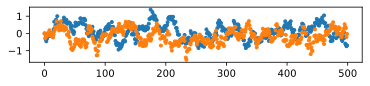

In [11]:

fig,ax = plt.subplots(figsize=(6,1))
ax.plot(trajectories[2,:,0].numpy(),".")
ax.plot(trajectories[300,:,0].numpy(),".")

In [12]:
trajectories[10,:,0].numpy()

array([ 0.00000000e+00, -7.38235377e-03, -1.19256042e-03,  1.42118841e-01,
        3.95844281e-01,  1.52932495e-01,  3.19935709e-01,  5.70538282e-01,
        4.97253478e-01,  5.89943886e-01,  5.49338698e-01,  7.86136627e-01,
        8.77237141e-01,  4.72626507e-01,  5.20897925e-01,  5.09642899e-01,
        4.27318692e-01,  1.86800271e-01, -3.92891467e-02,  2.54557848e-01,
       -6.85738027e-03, -1.02345191e-01, -2.03536481e-01, -1.87614352e-01,
       -1.67026743e-01, -2.43860692e-01, -1.84339330e-01, -1.72096461e-01,
       -3.72724831e-01, -3.58958960e-01, -4.13512707e-01, -6.04232132e-01,
       -6.35246933e-01, -4.85335529e-01, -8.81574690e-01, -8.88778031e-01,
       -1.21024013e+00, -1.07208478e+00, -1.29310405e+00, -1.50082421e+00,
       -1.38255882e+00, -1.16114116e+00, -1.23736107e+00, -1.04643941e+00,
       -5.85756660e-01, -3.51108372e-01, -3.04611892e-01, -1.78222075e-01,
       -3.02272201e-01, -4.46034461e-01, -4.89349246e-01, -4.05647099e-01,
       -5.16565740e-01, -

In [13]:
thetas.unsqueeze(1)

tensor([[1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
      

In [14]:
targets

tensor([[[ 0.0000,  0.0363,  0.0000],
         [ 0.1413,  0.0363,  0.0000],
         [ 0.0814,  0.0363,  0.0000],
         ...,
         [-0.0170,  0.0363,  0.0000],
         [-0.1010,  0.0363,  0.0000],
         [ 0.0342,  0.0363,  0.0000]],

        [[ 0.0000,  0.0363,  0.0000],
         [ 0.3235,  0.0363,  0.0000],
         [ 0.2912,  0.0363,  0.0000],
         ...,
         [ 0.1267,  0.0363,  0.0000],
         [ 0.0975,  0.0363,  0.0000],
         [-0.1263,  0.0363,  0.0000]],

        [[ 0.0000,  0.0363,  0.0000],
         [-0.0217,  0.0363,  0.0000],
         [-0.3161,  0.0363,  0.0000],
         ...,
         [-0.5909,  0.0363,  0.0000],
         [-0.6728,  0.0363,  0.0000],
         [-0.6305,  0.0363,  0.0000]],

        ...,

        [[ 0.0000,  0.0363,  0.0000],
         [-0.3879,  0.0363,  0.0000],
         [-0.2166,  0.0363,  0.0000],
         ...,
         [ 0.1665,  0.0363,  0.0000],
         [-0.0045,  0.0363,  0.0000],
         [-0.1940,  0.0363,  0.0000]],

        [[